In [ ]:
#importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
#Data Collection and Analysis
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
churn_data=pd.read_csv('/content/drive/MyDrive/Customer_churn_data.csv')

In [ ]:
churn_data.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Tariff Plan,Status,Age,Customer Value,FN,FP,Churn
0,8,0,38.0,0,4370,71.0,5.0,17.0,1,1,5,197.640,177.8760,69.7640,0
1,O,0,39.0,0,NaN,5.0,7.0,4.0,1,1,6,46.035,41.4315,60.0000,0
2,10,0,37.0,0,2453,60.0,359.0,24.0,1,1,2,1536.520,1382.8680,203.6520,0
3,10,0,38.0,0,4198,66.0,1.0,35.0,1,1,10,240.020,216.0180,74.0020,0
4,3,0,NaN,0,2393,58.0,2.0,33.0,1,1,9,145.805,131.2245,64.5805,0


In [ ]:
churn_data.describe()

,Subscription Length,Frequency of use,Frequency of SMS,Distinct Called Numbers,Tariff Plan,Status,Age,Customer Value,FN,FP,Churn
count,3145.000000,3131.000000,3146.000000,3148.000000,3150.000000,3150.000000,3150.000000,3058.000000,3150.000000,3150.000000,3150.000000
mean,32.333229,69.495688,73.262238,23.502541,1.077778,1.248254,34.820000,485.142147,423.875624,98.304688,0.157143
std,9.346742,57.798799,112.282285,17.227602,0.267864,0.432069,14.620541,518.143922,465.313890,50.724492,0.363993
min,-40.000000,-176.000000,-9.000000,0.000000,1.000000,1.000000,-13.000000,0.000000,0.000000,60.000000,0.000000
25%,29.000000,28.000000,6.000000,10.000000,1.000000,1.000000,25.000000,122.107500,102.421125,61.380125,0.000000
50%,35.000000,54.000000,21.000000,21.000000,1.000000,1.000000,34.000000,237.757500,205.632000,72.848000,0.000000
75%,38.000000,95.000000,87.750000,34.000000,1.000000,1.000000,42.000000,803.745000,709.549875,128.838875,0.000000
max,47.000000,255.000000,522.000000,97.000000,2.000000,2.000000,233.000000,2165.280000,1948.752000,266.528000,1.000000


In [ ]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3138 non-null   object 
 1   Complains                3137 non-null   object 
 2   Subscription  Length     3145 non-null   float64
 3   Charge  Amount           3148 non-null   object 
 4   Seconds of Use           3111 non-null   object 
 5   Frequency of use         3131 non-null   float64
 6   Frequency of SMS         3146 non-null   float64
 7   Distinct Called Numbers  3148 non-null   float64
 8   Tariff Plan              3150 non-null   int64  
 9   Status                   3150 non-null   int64  
 10  Age                      3150 non-null   int64  
 11  Customer Value           3058 non-null   float64
 12  FN                       3150 non-null   float64
 13  FP                       3150 non-null   float64
 14  Churn                   

In [ ]:
#checking for the null values in the given data
churn_data.isnull().sum()

,0
Call Failure,12
Complains,13
Subscription Length,5
Charge Amount,2
Seconds of Use,39
Frequency of use,19
Frequency of SMS,4
Distinct Called Numbers,2
Tariff Plan,0
Status,0


In [ ]:
#checking for the duplicate values in the given dataset
churn_data.duplicated().sum()

np.int64(18)

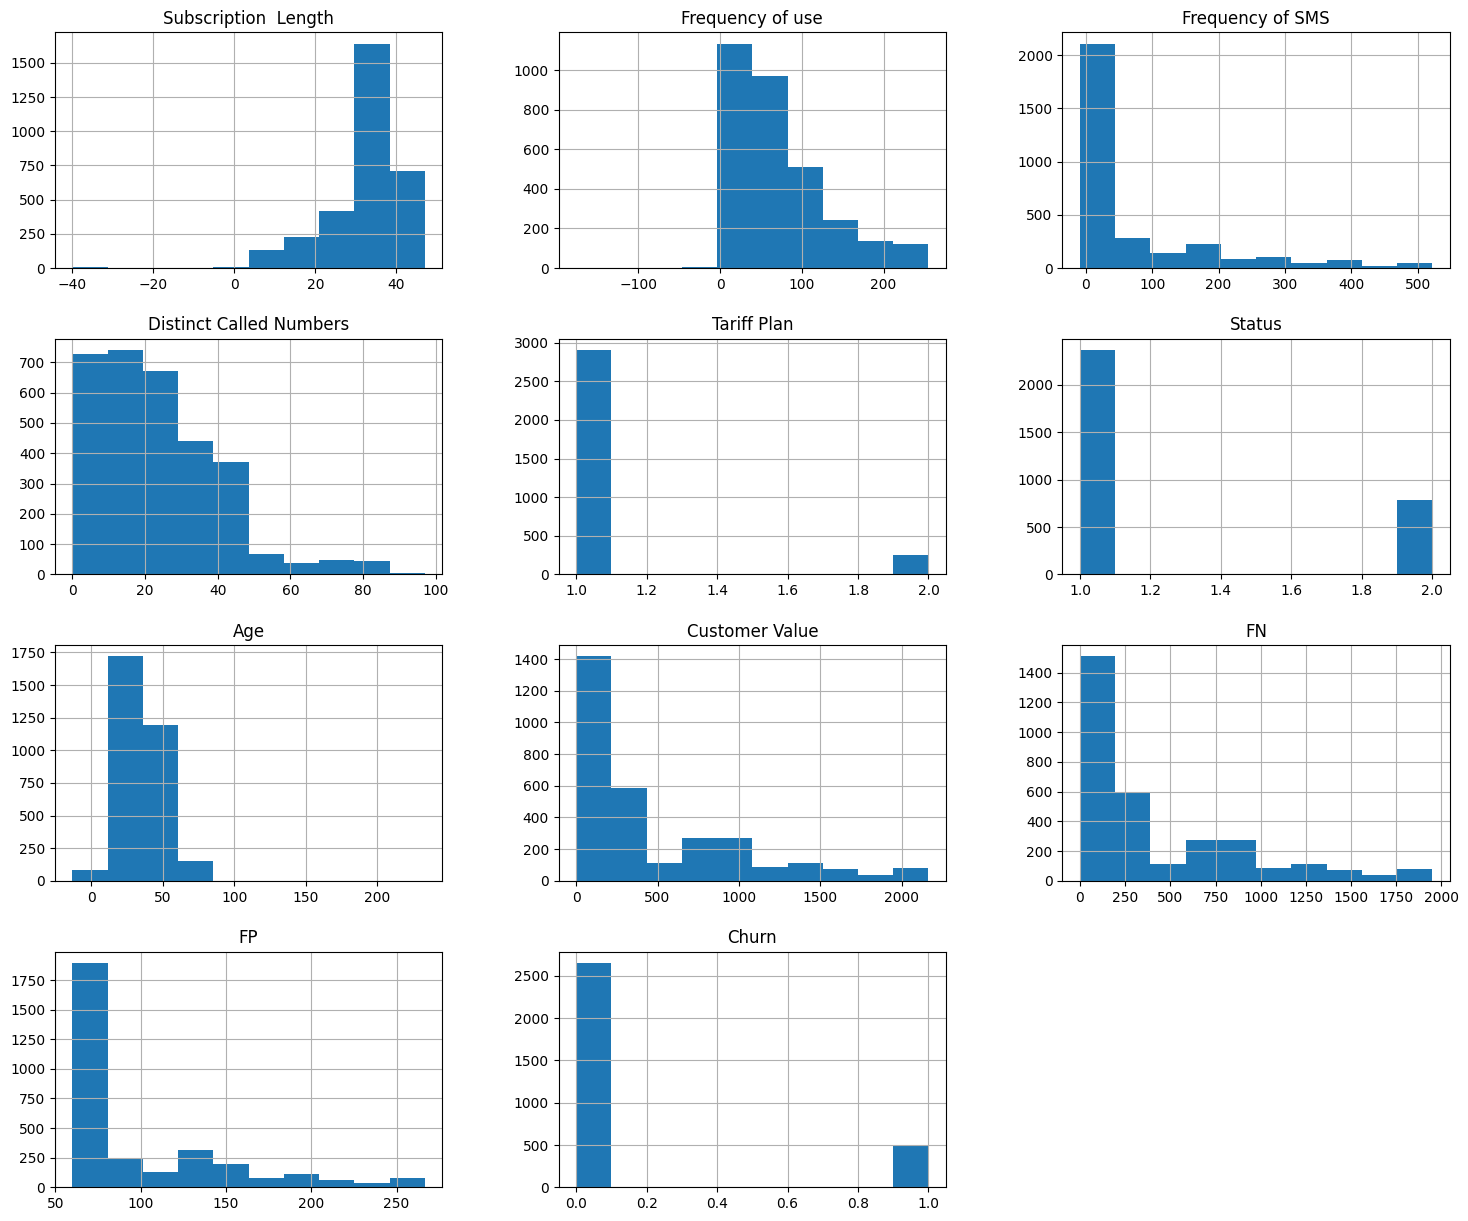

In [ ]:
#understanding the data distributions
churn_data.hist(figsize=(18,15))
plt.show()

In [ ]:
#handling the missing values replacing the column with the space with the _
churn_data.columns = churn_data.columns.str.replace(r'\s+', '_', regex=True)

In [ ]:
#replace the empty values with the value of the cell above it ffill
churn_data=churn_data.ffill()

In [ ]:
#converting numbers stroed as text into integer form
num_col=["Call_Failure","Charge_Amount","Seconds_of_Use"]
for col in num_col:
  churn_data[col]=pd.to_numeric(churn_data[col],errors='coerce')

#Converting of the categorical columns
cat_col=["Complains"]
le=LabelEncoder()
for col in cat_col:
  churn_data[col]=le.fit_transform(churn_data[col])

#fill the missing values with the median
churn_data = churn_data.fillna(churn_data.median())

In [ ]:
#model training
X = churn_data.drop('Churn', axis=1)
Y = churn_data['Churn']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)

In [ ]:
#feature scaling
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
#training of logistic regression model
model=LogisticRegression()
model.fit(X_train,Y_train)
prediction=model.predict(X_test)
accuracy=accuracy_score(Y_test,prediction)
print("\nClassification Report:\n",classification_report(Y_test,prediction))
print("\nConfusion Matrix:\n",confusion_matrix(Y_test,prediction))
print("\nAccuracy Score: {:.1f}".format(accuracy_score(Y_test, prediction) * 100))


Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       531
           1       0.71      0.34      0.46        99

    accuracy                           0.87       630
   macro avg       0.80      0.66      0.70       630
weighted avg       0.86      0.87      0.86       630


Confusion Matrix:
 [[517  14]
 [ 65  34]]

Accuracy Score: 87.5


In [ ]:
#decision tree learning
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,Y_train)
dt_prediction=dt_model.predict(X_test)
print("\nClassification Report:\n",classification_report(Y_test,dt_prediction))
print("\nConfusion Matrix:\n",confusion_matrix(Y_test,dt_prediction))
print("\nAccuracy Score: {:.1f}".format(accuracy_score(Y_test, dt_prediction) * 100))


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95       531
           1       0.77      0.63      0.69        99

    accuracy                           0.91       630
   macro avg       0.85      0.80      0.82       630
weighted avg       0.91      0.91      0.91       630


Confusion Matrix:
 [[512  19]
 [ 37  62]]

Accuracy Score: 91.1


In [ ]:
#naive bayes classifier
nb_model=GaussianNB()
nb_model.fit(X_train,Y_train)
nb_prediction=nb_model.predict(X_test)
print("\nClassification Report:\n",classification_report(Y_test,nb_prediction))
print("\nConfusion Matrix:\n",confusion_matrix(Y_test,nb_prediction))
print("\nAccuracy Score: {:.1f}".format(accuracy_score(Y_test, nb_prediction) * 100))


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.59      0.73       531
           1       0.28      0.87      0.43        99

    accuracy                           0.63       630
   macro avg       0.62      0.73      0.58       630
weighted avg       0.85      0.63      0.68       630


Confusion Matrix:
 [[312 219]
 [ 13  86]]

Accuracy Score: 63.2


In [ ]:
#random forest model
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,Y_train)
rf_prediction=rf_model.predict(X_test)
print("\nClassification Report:\n",classification_report(Y_test,rf_prediction))
print("\nConfusion Matrix:\n",confusion_matrix(Y_test,rf_prediction))
print("\nAccuracy Score: {:.1f}".format(accuracy_score(Y_test, rf_prediction) * 100))


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96       531
           1       0.88      0.61      0.72        99

    accuracy                           0.93       630
   macro avg       0.91      0.80      0.84       630
weighted avg       0.92      0.93      0.92       630


Confusion Matrix:
 [[523   8]
 [ 39  60]]

Accuracy Score: 92.5


In [ ]:
#knearest neighbours
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,Y_train)
knn_prediction=knn_model.predict(X_test)
print("\nClassification Report:\n",classification_report(Y_test,knn_prediction))
print("\nConfusion Matrix:\n",confusion_matrix(Y_test,knn_prediction))
print("\nAccuracy Score: {:.1f}".format(accuracy_score(Y_test, knn_prediction) * 100))


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95       531
           1       0.82      0.59      0.68        99

    accuracy                           0.91       630
   macro avg       0.87      0.78      0.82       630
weighted avg       0.91      0.91      0.91       630


Confusion Matrix:
 [[518  13]
 [ 41  58]]

Accuracy Score: 91.4


In [ ]:
#support vector machine
svm_model=SVC(kernel='rbf',C=1,random_state=42)
svm_model.fit(X_train,Y_train)
svm_prediction=svm_model.predict(X_test)
print("\nClassification Report:\n",classification_report(Y_test,svm_prediction))
print("\nConfusion Matrix:\n",confusion_matrix(Y_test,svm_prediction))
print("\nAccuracy Score: {:.1f}".format(accuracy_score(Y_test, svm_prediction) * 100))


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94       531
           1       0.88      0.38      0.54        99

    accuracy                           0.90       630
   macro avg       0.89      0.69      0.74       630
weighted avg       0.89      0.90      0.88       630


Confusion Matrix:
 [[526   5]
 [ 61  38]]

Accuracy Score: 89.5


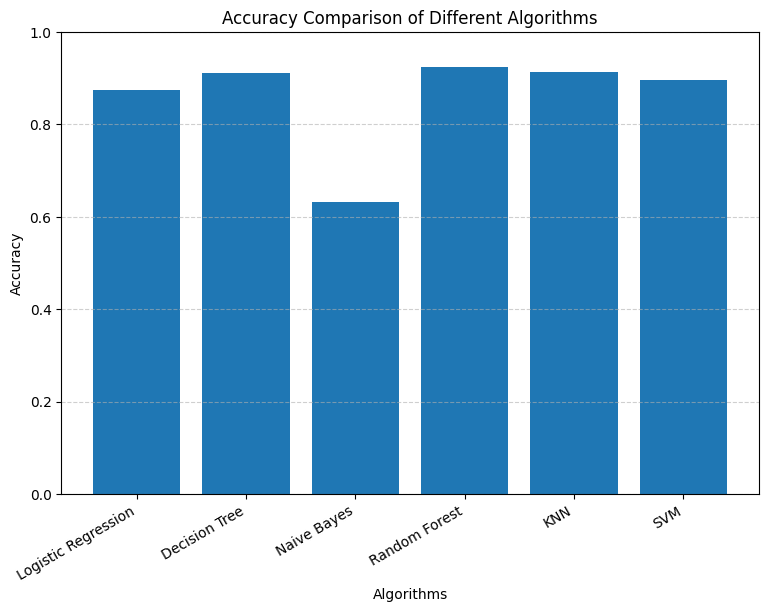

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Make sure to predict on X_test for each model
logreg_pred = model.predict(X_test)
dt_pred = dt_model.predict(X_test)
nb_pred = nb_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
knn_pred = knn_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

# Now calculate accuracies
accuracy_dict = {
    "Logistic Regression": accuracy_score(Y_test, logreg_pred),
    "Decision Tree": accuracy_score(Y_test, dt_pred),
    "Naive Bayes": accuracy_score(Y_test, nb_pred),
    "Random Forest": accuracy_score(Y_test, rf_pred),
    "KNN": accuracy_score(Y_test, knn_pred),
    "SVM": accuracy_score(Y_test, svm_pred)
}

# Extract model names and accuracy values
models = list(accuracy_dict.keys())
scores = list(accuracy_dict.values())

# Plot bar graph
plt.figure(figsize=(9, 6))
plt.bar(models, scores)
plt.ylim(0, 1)
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Different Algorithms")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


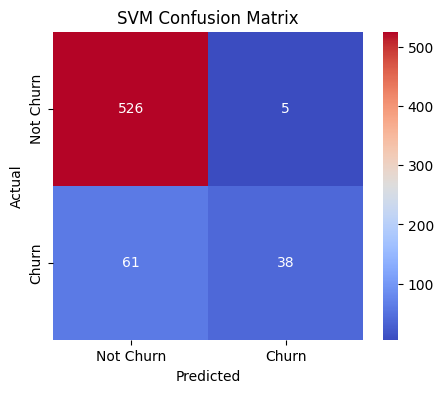

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(Y_test,svm_prediction)

# Plot heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=["Not Churn", "Churn"], yticklabels=["Not Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

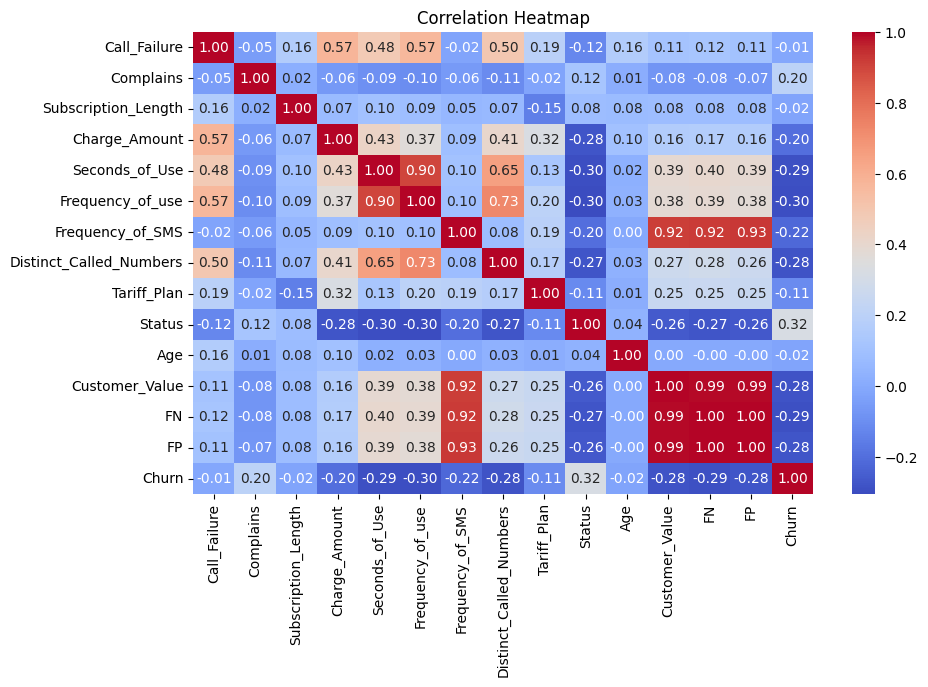

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(churn_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
import pandas as pd

# Get feature names from training data
feature_names = X.columns.tolist()

# Take user input for each feature
print("🔹 Please enter the values for the following features:")
input_values = []
for feature in feature_names:
    value = input(f"Enter value for {feature}: ")
    try:
        value = float(value)   # Convert to numeric
    except:
        pass  # Keep as string if categorical
    input_values.append(value)

# Convert to DataFrame
user_data = pd.DataFrame([input_values], columns=feature_names)

# Apply scaler/preprocessor
user_data_processed = scaler.transform(user_data)

# Predict churn
prediction = rf_model.predict(user_data_processed)

# Show result
if prediction[0] == 1:
    print("\n✅ The customer is likely to CHURN.")
else:
    print("\n✅ The customer is NOT likely to churn.")


🔹 Please enter the values for the following features:
Enter value for Call_Failure: 8
Enter value for Complains: 0
Enter value for Subscription_Length: 38
Enter value for Charge_Amount: 0
Enter value for Seconds_of_Use: 4370
Enter value for Frequency_of_use: 71
Enter value for Frequency_of_SMS: 5
Enter value for Distinct_Called_Numbers: 17
Enter value for Tariff_Plan: 1
Enter value for Status: 1
Enter value for Age: 5
Enter value for Customer_Value: 197.64
Enter value for FN: 177.876
Enter value for FP: 69.764

✅ The customer is NOT likely to churn.
